In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
print("tensorflow:", tf.__version__)

X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

tensorflow: 2.21.0
X_train: (242, 18)
X_test: (61, 18)
y_train: (242,)
y_test: (61,)


In [2]:
### input ( 18 features ) --> Dense (32 neuron) --> ReLu (activation fn) --> Dense (16) --> ReLu(activation fn) --> Dense (1) --> sigmoid ( converts the output between 0-1 )
## building the baseline model
model  = keras.Sequential([    ### sequential creates a empty model which process data through layers
    keras.layers.Input(shape=(18,)),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")

])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
### model compiling
model.compile(   ### compile -- configures the learning of the model
    optimizer = "adam", ### optimizer updates the weight during training
    loss = "binary_crossentropy",  ### loss tells how wrong is the model prediction is
    metrics = ["accuracy"]
)

In [4]:
### training the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5648 - loss: 0.7026 - val_accuracy: 0.4490 - val_loss: 0.7219
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5855 - loss: 0.6554 - val_accuracy: 0.5102 - val_loss: 0.6872
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6580 - loss: 0.6300 - val_accuracy: 0.5714 - val_loss: 0.6659
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7047 - loss: 0.6089 - val_accuracy: 0.5714 - val_loss: 0.6499
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7254 - loss: 0.5912 - val_accuracy: 0.5918 - val_loss: 0.6363
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7461 - loss: 0.5733 - val_accuracy: 0.6327 - val_loss: 0.6084
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7565 - loss: 0.5580 - val_accuracy: 0.6939 - val_loss: 0.5867
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7565 - loss: 0.5408 - val_accuracy: 0.7143 - val_lo

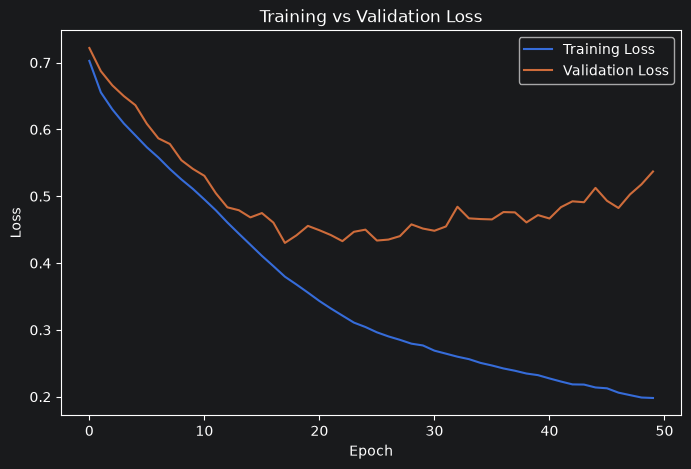

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

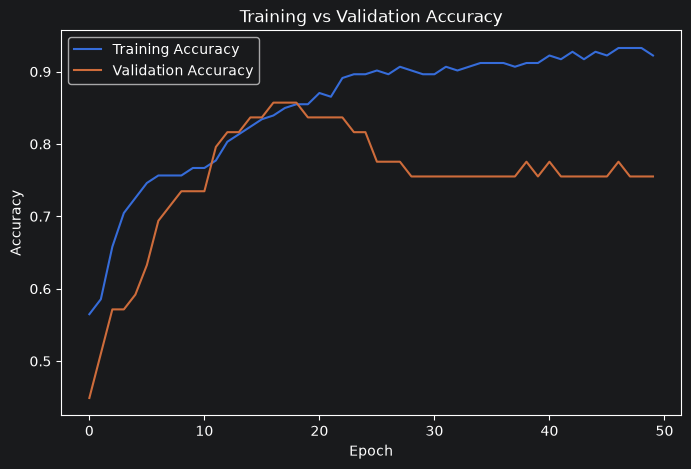

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [7]:
### early stopping call back
early_stopping = keras.callbacks.EarlyStopping(
    monitor = "val_loss",  ### which metrics to looks for
    patience = 5,    ### wait for 5 epoch if the val doesnt improve it stops
    restore_best_weights = True  ### restores the best weight
)

In [9]:
### training again with the changes
history_es = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9689 - loss: 0.0868 - val_accuracy: 0.6735 - val_loss: 0.8731
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9689 - loss: 0.0858 - val_accuracy: 0.6939 - val_loss: 0.8964
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9689 - loss: 0.0846 - val_accuracy: 0.6735 - val_loss: 0.9075
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9689 - loss: 0.0822 - val_accuracy: 0.6735 - val_loss: 0.9071
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9793 - loss: 0.0808 - val_accuracy: 0.6939 - val_loss: 0.9236
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9793 - loss: 0.0795 - val_accuracy: 0.6939 - val_loss: 0.9321


In [10]:
print("Epochs actually trained:", len(history_es.history["loss"]))

best_epoch = np.argmin(history_es.history["val_loss"]) + 1
best_val_loss = min(history_es.history["val_loss"])

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epochs actually trained: 6
Best epoch: 1
Best validation loss: 0.8730745315551758


In [11]:
### creating the model again
## fresh model
def  create_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(18,)),
        keras.layers.Dense(32,activation="relu"),
        keras.layers.Dense(16,activation="relu"),
        keras.layers.Dense(1,activation="sigmoid")
    ])
    model.compile(
        optimizer = "adam",
        loss = "binary_crossentropy",
        metrics = ["accuracy"]
    )
    return model

In [12]:
model_es = create_model()
model_es.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
### fresh callback
early_stopping_es = keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

In [14]:
history_es = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping_es],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9689 - loss: 0.0857 - val_accuracy: 0.6735 - val_loss: 0.8835
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9689 - loss: 0.0837 - val_accuracy: 0.6735 - val_loss: 0.8891
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9689 - loss: 0.0826 - val_accuracy: 0.6735 - val_loss: 0.8975
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9741 - loss: 0.0811 - val_accuracy: 0.6939 - val_loss: 0.9351
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9793 - loss: 0.0793 - val_accuracy: 0.6735 - val_loss: 0.9237
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9793 - loss: 0.0783 - val_accuracy: 0.6735 - val_loss: 0.9553


In [15]:
print("Epochs actually trained:", len(history_es.history["loss"]))

best_epoch = np.argmin(history_es.history["val_loss"]) + 1
best_val_loss = min(history_es.history["val_loss"])

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epochs actually trained: 6
Best epoch: 1
Best validation loss: 0.8835468888282776


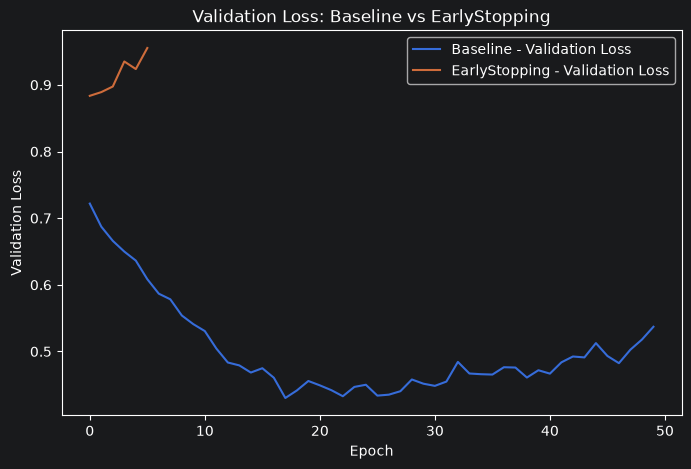

In [17]:
### visualize and compare the baseline and earlystopping ---- this is done to check whether the model is improved
## compare baseline loss and earlystopping loss
# to check does earlystopping improve model's generaization


### comparing validation loss
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["val_loss"],
    label="Baseline - Validation Loss"
)
plt.plot(
    history_es.history["val_loss"],
    label="EarlyStopping - Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Baseline vs EarlyStopping")

plt.legend()
plt.show()


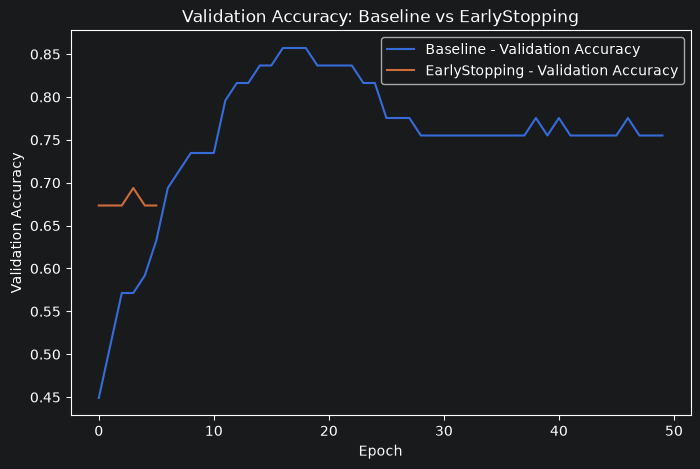

In [18]:
### comparing validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["val_accuracy"],
    label = "Baseline - Validation Accuracy"

)
plt.plot(
    history_es.history["val_accuracy"],
    label = "EarlyStopping - Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Baseline vs EarlyStopping")
plt.legend()
plt.show()


In [19]:
### regularization --- dropout model
def create_dropout_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(18,)),

        keras.layers.Dense(32,activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(16,activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1,activation="sigmoid")
    ])
    model.compile(
        optimizer = "adam",
        loss = "binary_crossentropy",
        metrics = ["accuracy"]
    )
    return model


In [20]:
model_dropout = create_dropout_model()
model_dropout.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stopping_dropout = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [22]:
history_dropout = model_dropout.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping_dropout],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6166 - loss: 0.6917 - val_accuracy: 0.4286 - val_loss: 0.7142
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5855 - loss: 0.6671 - val_accuracy: 0.4490 - val_loss: 0.6933
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6218 - loss: 0.6477 - val_accuracy: 0.5102 - val_loss: 0.6752
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6425 - loss: 0.6183 - val_accuracy: 0.5714 - val_loss: 0.6574
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6736 - loss: 0.6151 - val_accuracy: 0.7143 - val_loss: 0.6377
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6839 - loss: 0.5816 - val_accuracy: 0.7347 - val_loss: 0.6296
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7202 - loss: 0.5760 - val_accuracy: 0.7347 - val_loss: 0.6077
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7358 - loss: 0.5559 - val_accuracy: 0.7347 - val_loss

In [23]:
print("Epochs actually trained:", len(history_dropout.history["loss"]))

best_epoch_dropout = np.argmin(
    history_dropout.history["val_loss"]
) + 1

best_val_loss_dropout = min(
    history_dropout.history["val_loss"]
)

best_val_accuracy_dropout = max(
    history_dropout.history["val_accuracy"]
)

print("Best epoch:", best_epoch_dropout)
print("Best validation loss:", best_val_loss_dropout)
print("Best validation accuracy:", best_val_accuracy_dropout)

Epochs actually trained: 21
Best epoch: 16
Best validation loss: 0.46533024311065674
Best validation accuracy: 0.8367347121238708


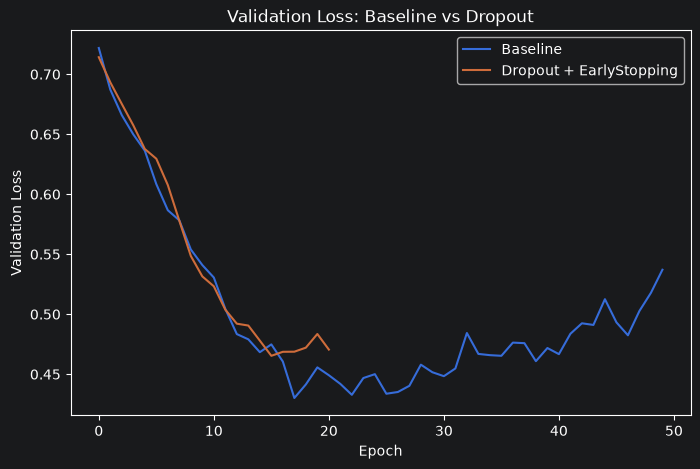

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    label="Baseline"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Dropout + EarlyStopping"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Baseline vs Dropout")
plt.legend()
plt.show()

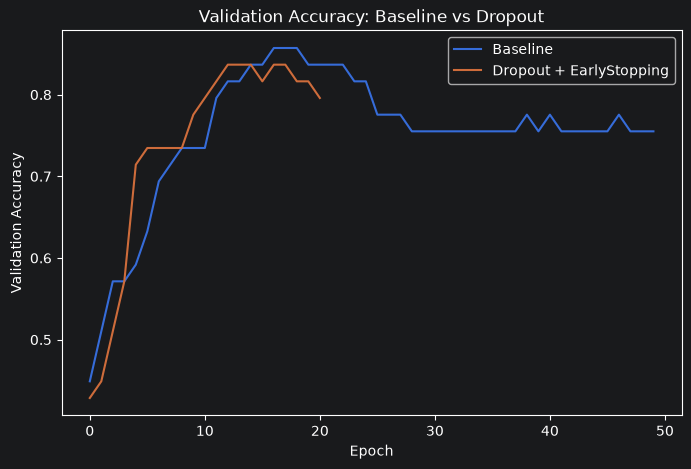

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    label="Baseline"
)

plt.plot(
    history_dropout.history["val_accuracy"],
    label="Dropout + EarlyStopping"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Baseline vs Dropout")
plt.legend()
plt.show()

In [26]:
### evaluating the drop out model
test_loss , test_accuracy = model_dropout.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("test loss:", test_loss)
print("test accuracy:", test_accuracy)

test loss: 0.40911421179771423
test accuracy: 0.8196721076965332


In [27]:
### evaluating the baseline model too
baseline_test_loss, baseline_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("baseline test loss:", baseline_test_loss)
print("baselinee test accuracy:", baseline_accuracy)

baseline test loss: 0.6460558772087097
baselinee test accuracy: 0.8196721076965332


In [ ]:
### tho both model ( baseline and dropout ) have same accuracy but the loss is different which tells the confidence of the model . accuracy checks whether the prediction is correct or not but the loss tells how correct and confidence of the prediction

In [28]:
### probabilites from dropout model
y_prob_dropout = model_dropout.predict(
    X_test,
    verbose=0
).ravel() ## ravel() flatens multidimensional array into 1D
y_pred_dropout = (y_prob_dropout >=0.5).astype(int)

print("first 10 probabilities: ", y_prob_dropout[:10])
print("first 10 predictions:", y_pred_dropout[:10])

first 10 probabilities:  [0.20030068 0.74392796 0.16492514 0.05403543 0.6699096  0.405126
 0.17568511 0.5873984  0.58174044 0.15386379]
first 10 predictions: [0 1 0 0 1 0 0 1 1 0]


In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_dropout)
print (" confusion matrix:")
print(cm)

 confusion matrix:
[[25  8]
 [ 3 25]]


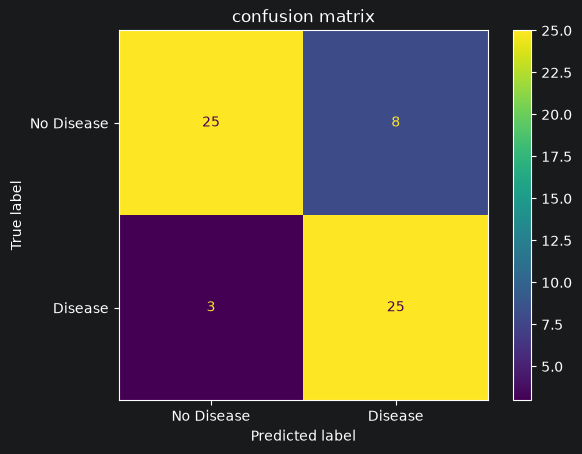

In [31]:
### representing the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]

).plot()
plt.title("confusion matrix")
plt.show()

In [32]:
from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score
 )
accuracy = accuracy_score(y_test, y_pred_dropout)
precision = precision_score(y_test, y_pred_dropout)
recall = recall_score(y_test, y_pred_dropout)
f1 = f1_score(y_test, y_pred_dropout)
print("accuracy:", accuracy)
print("precision:", precision)
print("recall:", recall)
print("f1:",f1)



accuracy: 0.819672131147541
precision: 0.7575757575757576
recall: 0.8928571428571429
f1: 0.819672131147541


In [34]:
from sklearn.metrics import classification_report
report = classification_report(
    y_test,
    y_pred_dropout,
    target_names = ["No Disease", "Disease"]
)
print(report)

              precision    recall  f1-score   support

  No Disease       0.89      0.76      0.82        33
     Disease       0.76      0.89      0.82        28

    accuracy                           0.82        61
   macro avg       0.83      0.83      0.82        61
weighted avg       0.83      0.82      0.82        61



In [35]:
### creating ROC and AUROC
from sklearn.metrics import roc_curve , roc_auc_score
fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob_dropout
)
auroc = roc_auc_score(
    y_test,
    y_prob_dropout
)

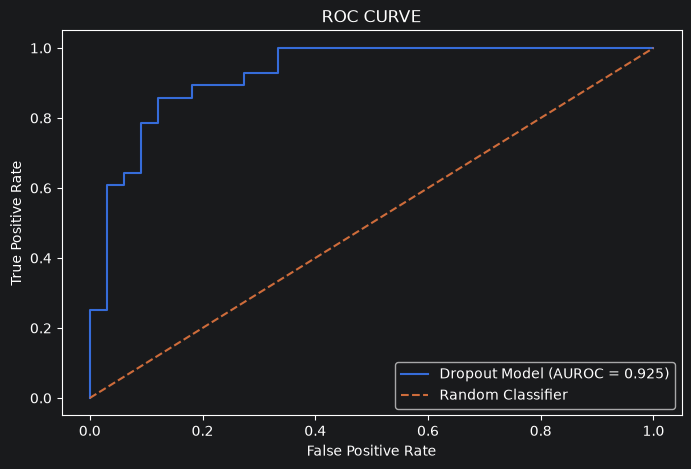

In [37]:
### ploting the curve
plt.figure(figsize=(8, 5))
plt.plot(
    fpr, ### fpr xaxis
    tpr,  ### tpr yaxis
    label=f"Dropout Model (AUROC = {auroc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()